In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_excel("/content/태림_필터링데이터(찐).xlsx")

In [5]:
df.head()

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,May,2024,27,4.8,pc,FIRM,SEA,NaN,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,June,2024,3,4.8,pc,FIRM,SEA,NaN,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,June,2024,10,6.4,pc,FIRM,SEA,NaN,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,June,2024,26,6.4,pc,FORECAST,SEA,NaN,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,July,2024,4,6.4,pc,FORECAST,SEA,NaN,1.656.750


In [8]:
# =========================
# ⭐ EDA 기본 설정 셀
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!apt-get install -y fonts-nanum

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [11]:
# ==========================================
# ⭐ 코랩 한글 폰트
# ==========================================
!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 직접 지정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print("적용된 폰트:", fontprop.get_name())

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 19 not upgraded.
적용된 폰트: NanumGothic


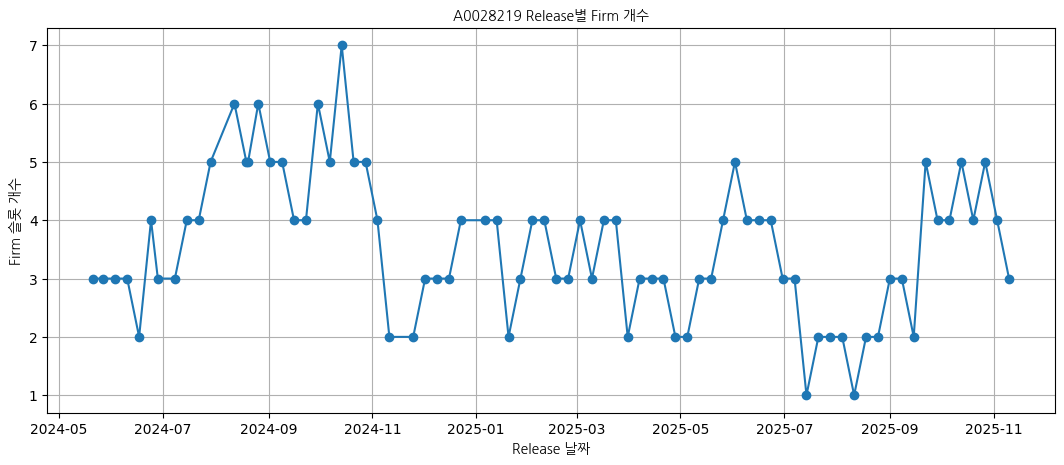

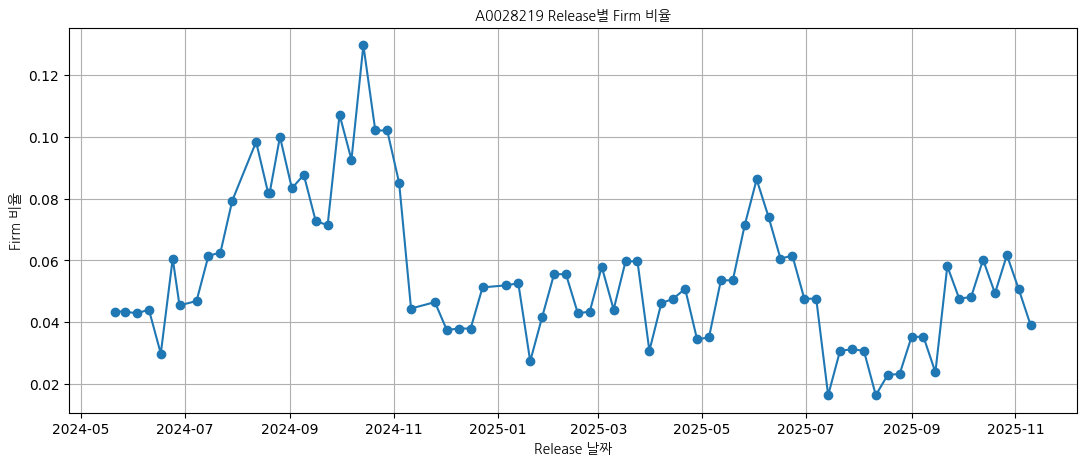

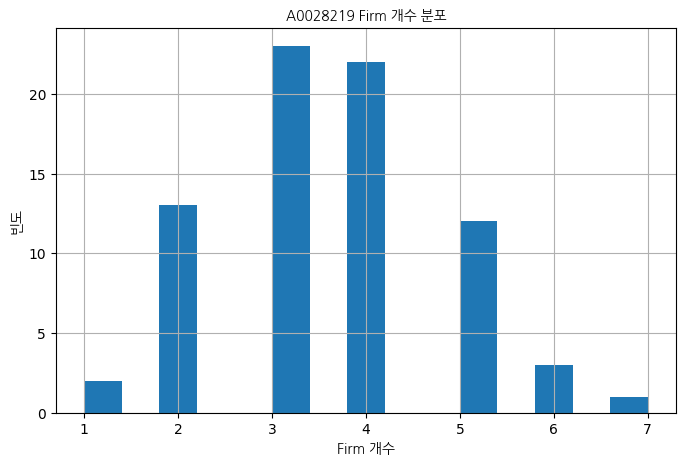

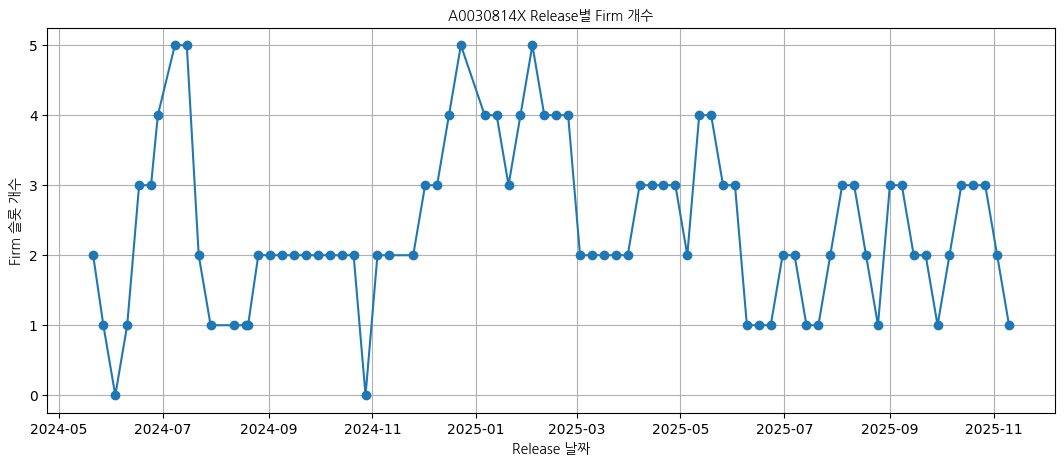

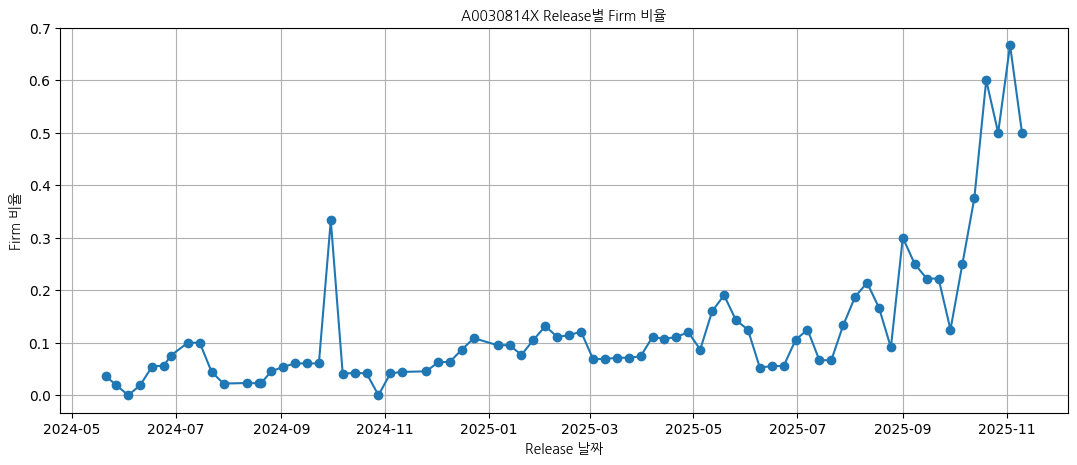

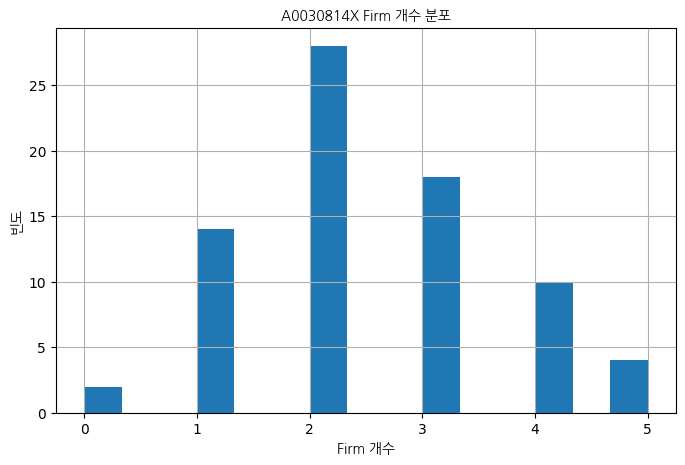

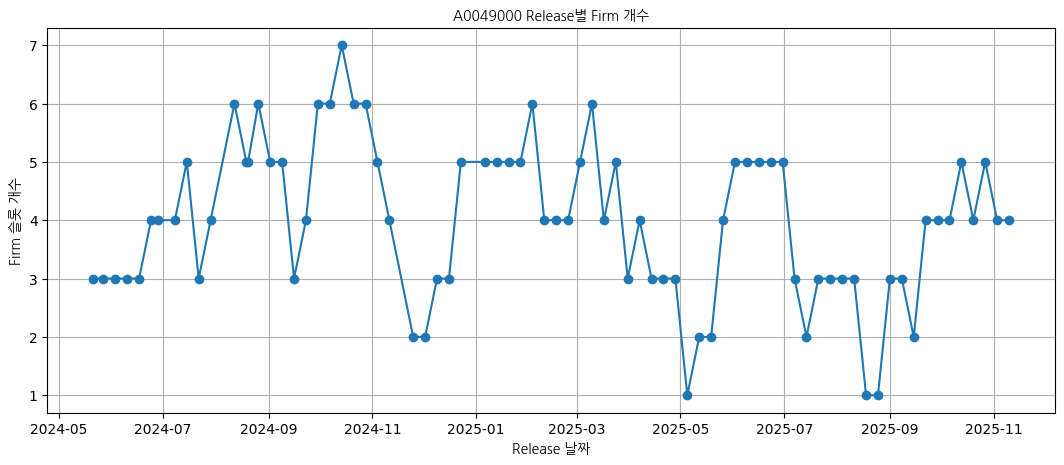

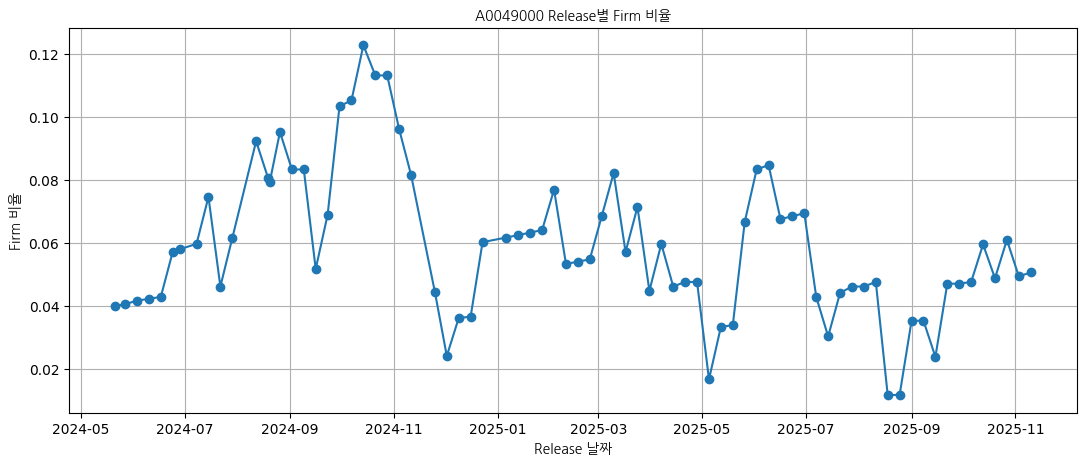

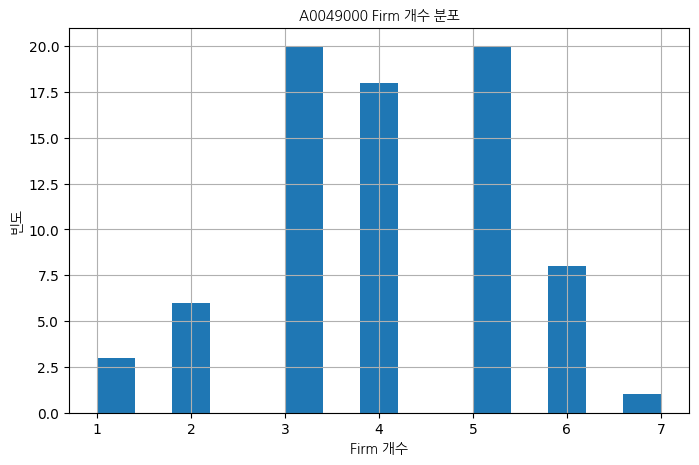

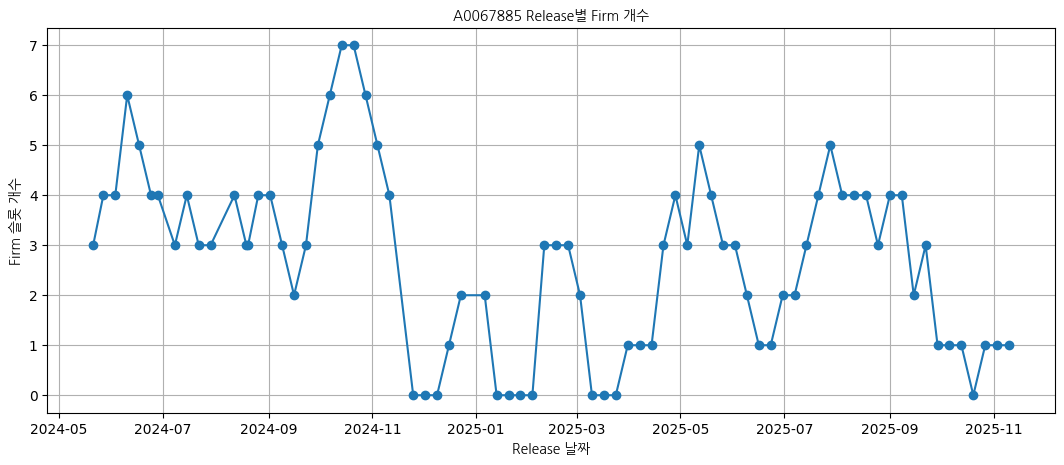

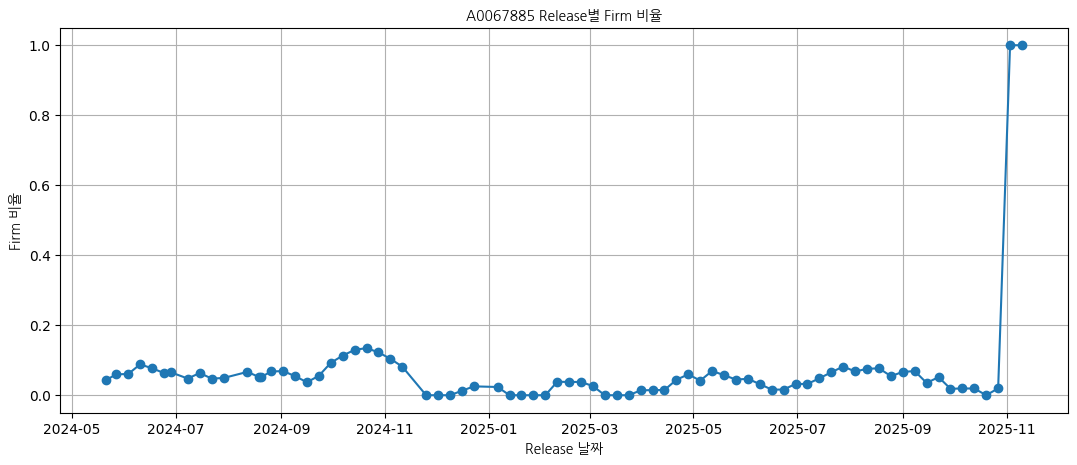

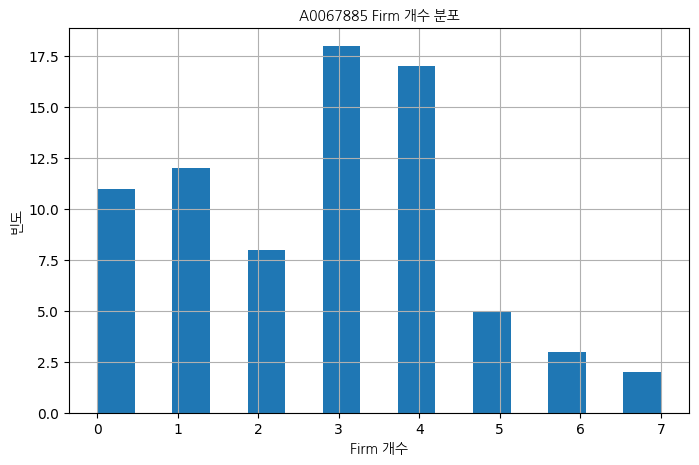

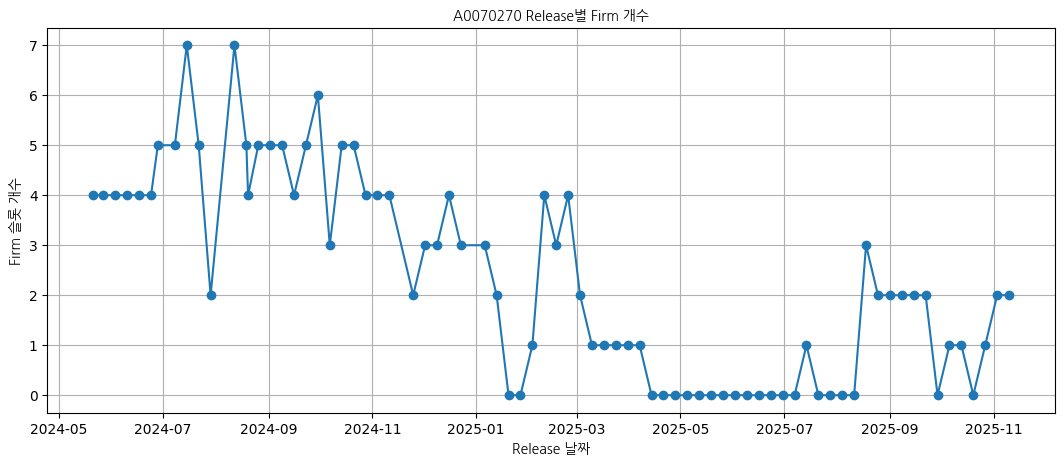

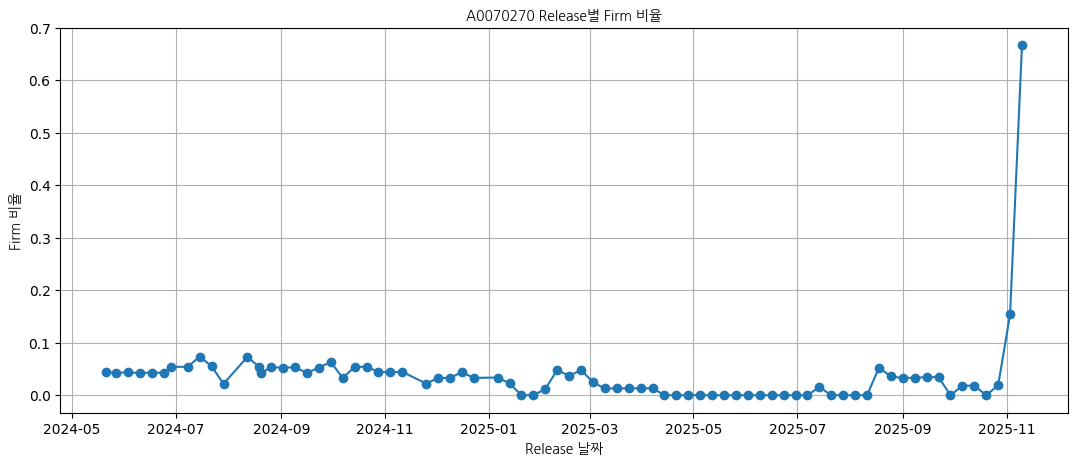

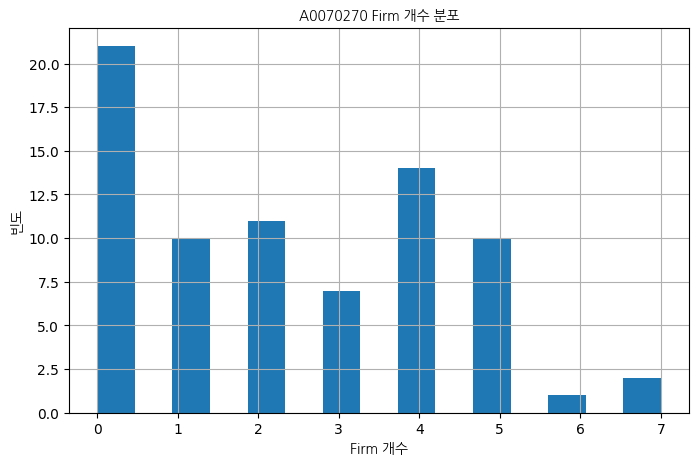

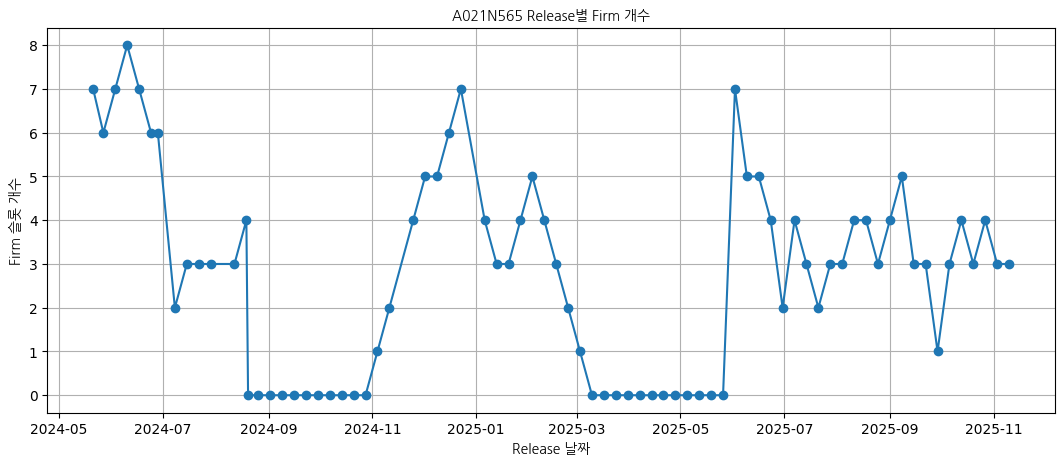

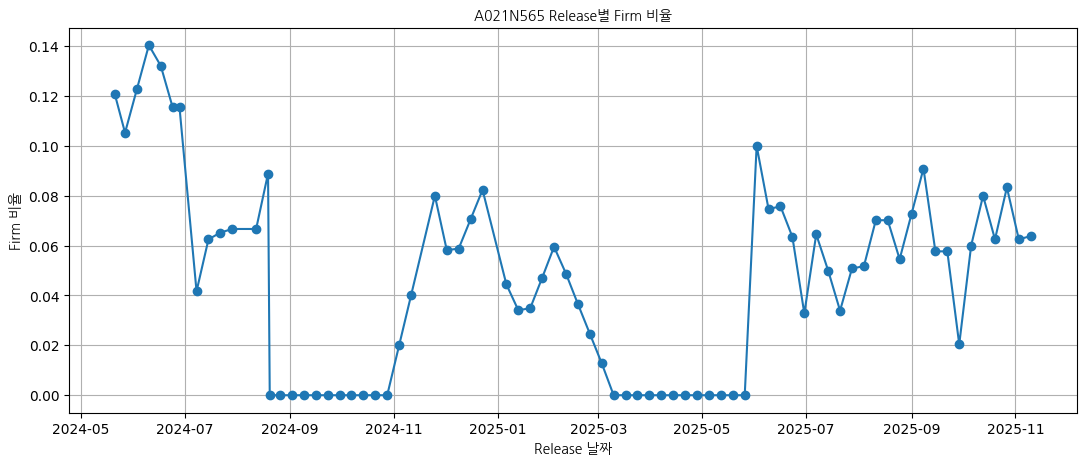

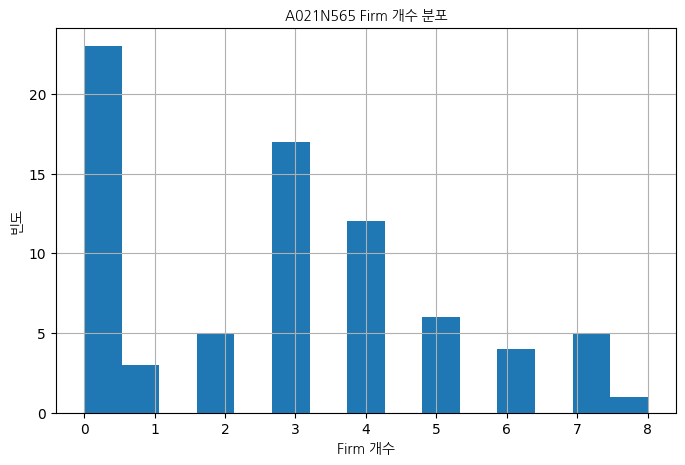

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ================================
# ⭐ 한글 폰트 직접 로드 (핵심)
# ================================
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fontprop = fm.FontProperties(fname=font_path)

# ================================
# 데이터 불러오기
# ================================
df = pd.read_excel("/content/태림_필터링데이터(찐).xlsx")

# release 날짜 생성
df["release_date"] = pd.to_datetime(df["ID_Release"].str[:8], format="%Y%m%d")

# 출하 예정일 생성
df["ship_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str)
)

# ship_slot 생성
df["ship_slot"] = df["ZF_PN"].astype(str) + "_" + df["ship_date"].astype(str)

# firm 여부
df["is_firm"] = (df["Firm/Forecast"] == "FIRM").astype(int)

products = df["ZF_PN"].unique()

for pn in products:

    temp = df[df["ZF_PN"] == pn].copy()
    temp = temp.sort_values("release_date")

    temp = temp.drop_duplicates(["release_date","ship_slot"], keep="last")

    firm_count = temp.groupby("release_date")["is_firm"].sum()
    total_count = temp.groupby("release_date")["ship_slot"].count()
    firm_ratio = firm_count / total_count

    # ================================
    # ⭐ 그래프1 Firm 개수
    # ================================
    plt.figure(figsize=(13,5))
    plt.plot(firm_count.index, firm_count.values, marker='o')
    plt.title(f"{pn} Release별 Firm 개수", fontproperties=fontprop)
    plt.xlabel("Release 날짜", fontproperties=fontprop)
    plt.ylabel("Firm 슬롯 개수", fontproperties=fontprop)
    plt.grid()
    plt.show()

    # ================================
    # ⭐ 그래프2 Firm 비율
    # ================================
    plt.figure(figsize=(13,5))
    plt.plot(firm_ratio.index, firm_ratio.values, marker='o')
    plt.title(f"{pn} Release별 Firm 비율", fontproperties=fontprop)
    plt.xlabel("Release 날짜", fontproperties=fontprop)
    plt.ylabel("Firm 비율", fontproperties=fontprop)
    plt.grid()
    plt.show()

    # ================================
    # ⭐ 그래프3 Firm 개수 분포
    # ================================
    plt.figure(figsize=(8,5))
    plt.hist(firm_count.values, bins=15)
    plt.title(f"{pn} Firm 개수 분포", fontproperties=fontprop)
    plt.xlabel("Firm 개수", fontproperties=fontprop)
    plt.ylabel("빈도", fontproperties=fontprop)
    plt.grid()
    plt.show()